In [1]:
import glob
import logging
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from astropy.io import fits
import healpy as hp
import matplotlib.patches as patches
from matplotlib.path import Path
from astropy import wcs
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import astropy.units as u
from photutils.psf import fit_fwhm
# ── configure logging (optional — mopsf uses the standard logging module) ────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(message)s",
    datefmt="%H:%M:%S",
)

# ── import mopsf modules ──────────────────────────────────────────────────────
from mopsf.psf_model import build_psf_cache
from mopsf.inject    import make_mock_exposures
from mopsf.pipeline  import run_pipeline
from mopsf.measure   import build_epsf, find_mosaic, load_mosaic

19:10:51  INFO  Note: detected 192 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
19:10:51  INFO  Note: NumExpr detected 192 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
19:10:51  INFO  NumExpr defaulting to 16 threads.
19:12:22  WARNING  **WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-068 CANNOT BE CHECKED AGAINST ONLINE VERSION


In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CONFIGURATION — edit these paths and settings
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

MAIN_DIR    = "/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/"
FILTER      = "F115W"
MPSF_DIR    = MAIN_DIR + f'mpsf/{FILTER}'
PIXEL_SCALE = 0.031    # arcsec/px — LW: 0.063, SW: 0.031
PIXEL_SCALE_MOSAIC = 0.02  

# Input: real Stage 3 cal.fits files
CAL_FILES = sorted(glob.glob(os.path.join(MAIN_DIR, f"direct_image_{FILTER}", "stage3", f"*_a3001_crf.fits")))
print(len(CAL_FILES), CAL_FILES)
# Output dirs (created automatically)
# The mock cal.fits go directly into Resampling.
INJECTED_DIR = os.path.join(MPSF_DIR, "mpsf_injected")
STAGE3_DIR   = os.path.join(MPSF_DIR, "mpsf_stage3")
MOSAIC_DIR   = os.path.join(MPSF_DIR, "mpsf_mosaic")
OUTPUT_DIR   = os.path.join(MPSF_DIR, "mpsf_output")

# Pipeline inputs (same as real-data run)
LW_DIR   = os.path.join(MPSF_DIR, "lw")
ASN_DIR  = os.path.join(MPSF_DIR, "asn")
WISP_DIR = os.path.join(MPSF_DIR, "wisp_templates")
PIXFRAC  = 0.75   # must match real-data resample

384 ['/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrca1_a3001_crf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrca2_a3001_crf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrca3_a3001_crf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrca4_a3001_crf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrcb1_a3001_crf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrcb2_a3001_crf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrcb3_a3001_crf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nr

In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STEP 1 — build stpsf PSFs and inject into mock cal.fits
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"\n{'='*60}")
print(f"  STEP 1 — PSF model + injection  [{FILTER}]")
print(f"{'='*60}\n")

# Build one PSF per unique detector found in the cal.fits headers
# (cached so stpsf is only called once per detector)
psf_cache = build_psf_cache(
    filter_name = FILTER,
    cal_files   = CAL_FILES,
    pixel_scale = PIXEL_SCALE,
    add_ipc     = True,   
    fov_pixels  = 71,
)

# Inject into mock exposures
mock_files = make_mock_exposures(
    cal_files   = CAL_FILES,
    psf_cache   = psf_cache,
    filter_name = FILTER,
    out_dir     = INJECTED_DIR,
    peak_counts = 1000.0,
)
print(f"\nInjected {len(mock_files)} mock exposures → {INJECTED_DIR}\n")


  STEP 1 — PSF model + injection  [F115W]



10:59:34  INFO  NIRCam aperture name updated to NRCA1_FULL
10:59:34  INFO  stpsf: filter=F115W  detector=NRCA1  pixel_scale=0.0310  IPC=True
10:59:34  INFO  No source spectrum supplied, therefore defaulting to 5700 K blackbody
10:59:34  INFO  Computing wavelength weights using synthetic photometry for F115W...
10:59:34  INFO  PSF calc using fov_pixels = 71, oversample = 4, number of wavelengths = 21
10:59:34  INFO  Creating optical system model:
10:59:34  INFO  Initialized OpticalSystem: JWST+NIRCam
10:59:34  INFO  JWST Entrance Pupil: Loaded amplitude transmission from /home/zhanghan/data/stpsf-data/jwst_pupil_RevW_npix1024.fits.gz
10:59:34  INFO  JWST Entrance Pupil: Loaded OPD from /home/zhanghan/data/stpsf-data/JWST_OTE_OPD_cycle1_example_2022-07-30.fits
10:59:34  INFO  Loading field dependent model parameters from /home/zhanghan/data/stpsf-data/NIRCam/OPD/field_dep_table_nircam.fits
10:59:34  INFO  Calculating field-dependent OTE OPD at v2 = 2.010 arcmin, v3 = -8.792 arcmin
10:59:


Injected 384 mock exposures → /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_injected



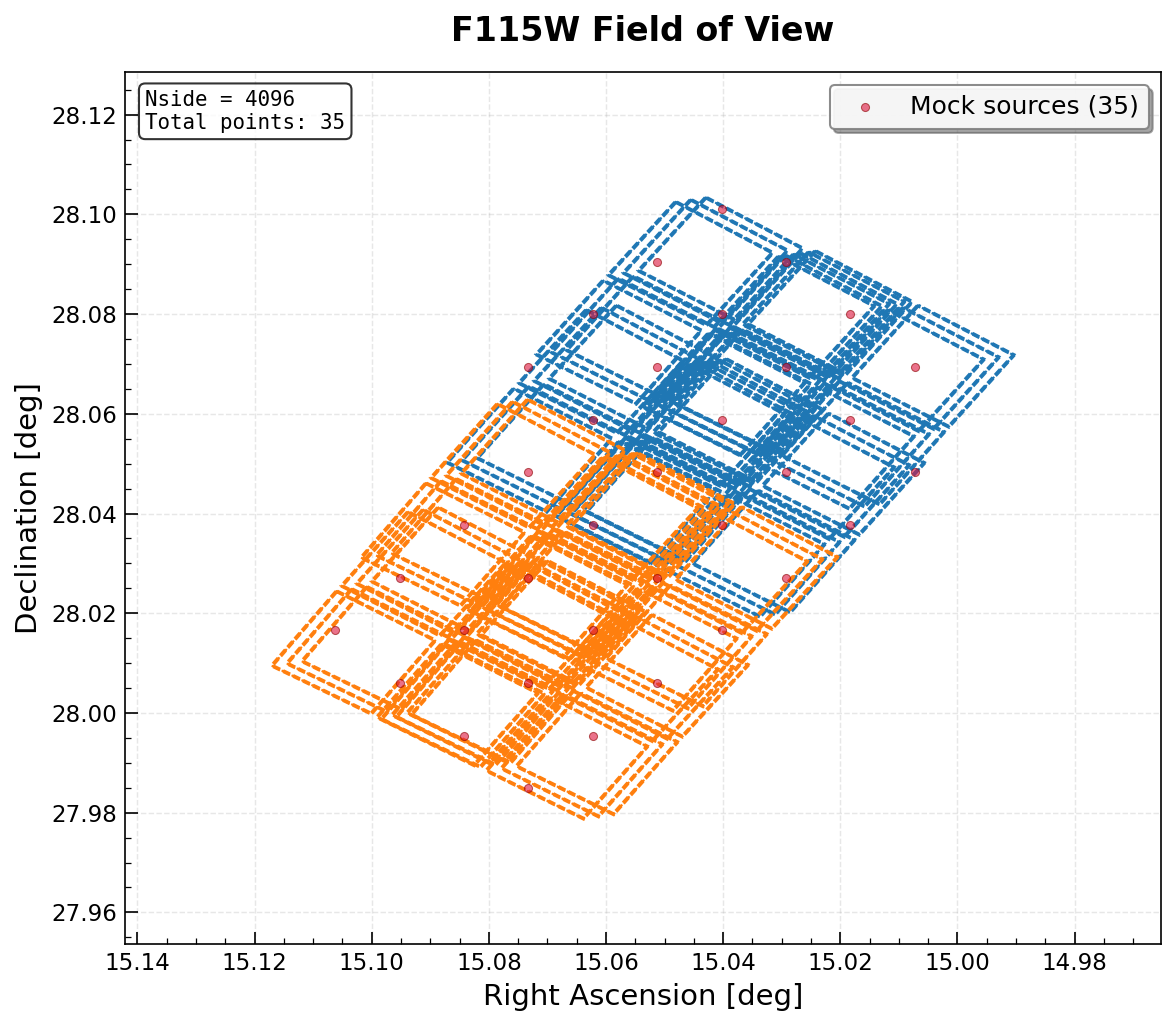

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Visualize the footprint of mock stars
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
warnings.filterwarnings('ignore')
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['figure.dpi'] = 150

nside = 2**12   # ~6 injection sites per NIRCam module
npix  = hp.nside2npix(nside)
ipix  = np.arange(npix)
theta, phi = hp.pix2ang(nside, ipix, lonlat=False)
dec_hp = 90.0 - np.degrees(theta)
ra_hp  = np.degrees(phi)

# coordinates in Science frame
sci_x = np.array([0, 2047, 2047, 0])
sci_y = np.array([0, 0, 2047, 2047])

fig, ax = plt.subplots(1, 1, figsize=(8, 7))
module_colors = {'A': '#1f77b4', 'B': '#ff7f0e'}
module_labels = {'A': 'Module A', 'B': 'Module B'}


for i, tmp_cal_path in enumerate(CAL_FILES):
    tmp_module = fits.getheader(tmp_cal_path)['module']
    tmp_color = module_colors[tmp_module]
    
    tmp_grism_hd_sci = fits.getheader(tmp_cal_path, 'sci')
    tmp_grism_hd_wcs = wcs.WCS(tmp_grism_hd_sci)
    coords_corners = wcs.utils.pixel_to_skycoord(sci_x, sci_y, tmp_grism_hd_wcs)
    coords_corners = np.array([coords_corners.ra.value, coords_corners.dec.value]).T

    # Plot polygons with nicer styling
    line_fullcov = patches.Polygon(
        coords_corners, 
        facecolor='none', 
        edgecolor=tmp_color, 
        linewidth=1.0,
        linestyle='--',
        closed=True
    )
    ax.add_patch(line_fullcov)
    #ax.scatter(coords_corners[:, 0], coords_corners[:, 1], 
    #          color=tmp_color, s=30, zorder=5, edgecolors='white', linewidth=1)
    if i == 0: 
        all_corners = coords_corners
    else: 
        all_corners = np.vstack((all_corners, coords_corners))

from scipy.spatial import ConvexHull
hull = ConvexHull(all_corners)
footprint_corners = all_corners[hull.vertices]
footprint_path = Path(footprint_corners)
points = np.column_stack((ra_hp, dec_hp))
mask_inside = footprint_path.contains_points(points)

ra_hp_filtered = ra_hp[mask_inside]
dec_hp_filtered = dec_hp[mask_inside]

xmin = np.max(all_corners[:,0]) + 1.5/60
xmax = np.min(all_corners[:,0]) - 1.5/60
ymin = np.min(all_corners[:,1]) - 1.5/60
ymax = np.max(all_corners[:,1]) + 1.5/60
ax.scatter(ra_hp_filtered, dec_hp_filtered, 
          marker='o', 
          color='crimson', 
          s=15,  # Smaller, more elegant size
          alpha=0.6,
          edgecolors='darkred',
          linewidth=0.5,
          zorder=3,
          label=f'Mock sources ({len(ra_hp_filtered)})')

ax.set(xlim=(xmin, xmax),
       ylim=(ymin, ymax),
       xlabel='Right Ascension [deg]',
       ylabel='Declination [deg]')
ax.set_title(f'{FILTER} Field of View', fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)  # Put grid behind other elements
ax.legend(loc='upper right', framealpha=0.9, edgecolor='gray', fancybox=True, shadow=True)
ax.text(0.02, 0.98, f'Nside = {nside}\nTotal points: {len(ra_hp_filtered)}', 
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
        fontsize=10, family='monospace')
ax.tick_params(axis='both', which='major', labelsize=11, direction='in', length=6)
ax.tick_params(axis='both', which='minor', labelsize=9, direction='in', length=3)
ax.minorticks_on()
plt.tight_layout()

# Save if desired (uncomment to save)
# plt.savefig(f'{FILTER}_FOV.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

8


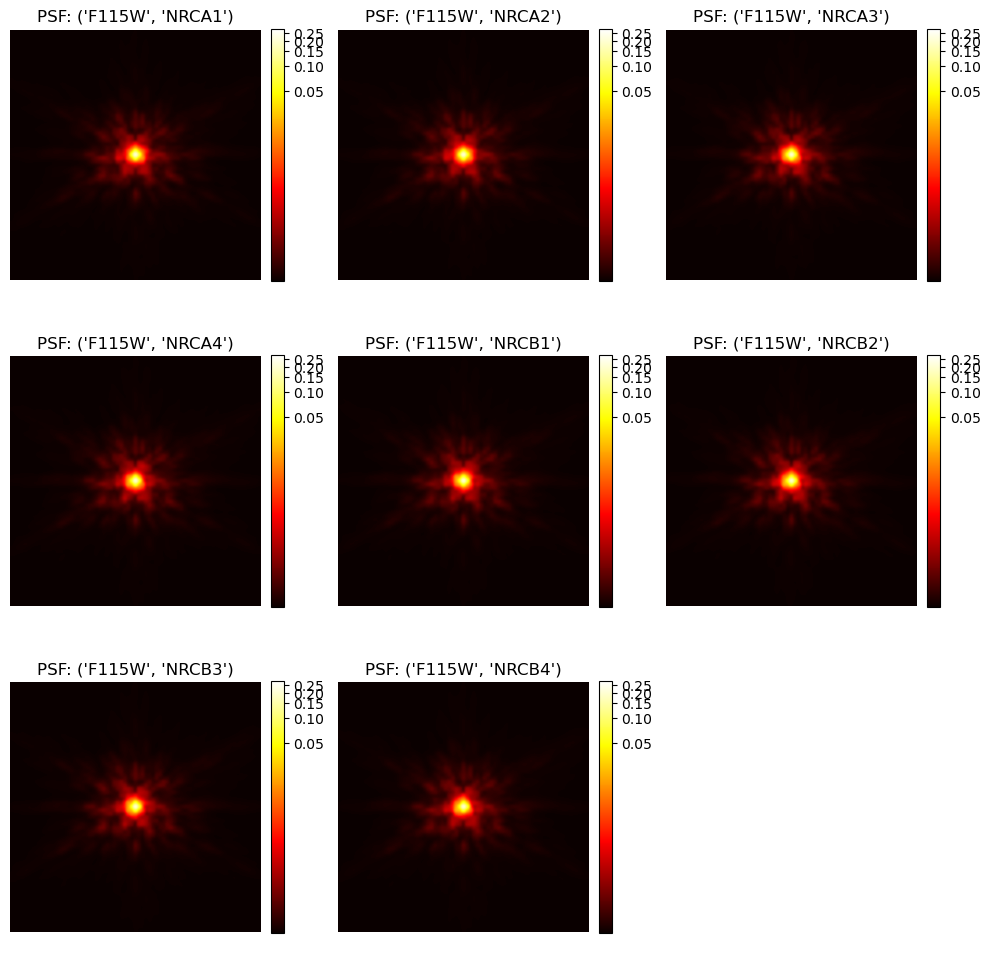

In [20]:
%matplotlib inline
print(len(psf_cache))
nrow = int(np.ceil(len(psf_cache)/3))
fig, axs = plt.subplots(nrow, 3, figsize=(12, 4*nrow))
axs = axs.flatten()
norm = None
for ax in axs:
    ax.axis('off')
for i, key in enumerate(psf_cache):
    psf = psf_cache[key]
    if norm is None:
        norm = simple_norm(psf, stretch='log')
    im = axs[i].imshow(psf, cmap='hot', norm=norm, interpolation='gaussian', origin='lower')
    axs[i].set_title(f"PSF: {key}")
    plt.colorbar(im, ax=axs[i], fraction=0.046, pad=0.04)
plt.show()

In [ ]:
print("="*60)
for i, key in enumerate(psf_cache):
    psf = psf_cache[key]
    print(f"FWHM for {key}")
    print(f"pixel scale = {PIXEL_SCALE} arcsec/pixel")
    fwhm_stpsf = fit_fwhm(psf)[0] * PIXEL_SCALE
    print(f"PSF FWHM = {fwhm_stpsf} arcsec")

FWHM for ('F115W', 'NRCA1')
pixel scale = 0.031 arcsec/pixel
PSF FWHM = 0.03953482795530116 arcsec
FWHM for ('F115W', 'NRCA2')
pixel scale = 0.031 arcsec/pixel
PSF FWHM = 0.03953919769763845 arcsec
FWHM for ('F115W', 'NRCA3')
pixel scale = 0.031 arcsec/pixel
PSF FWHM = 0.040064802659142085 arcsec
FWHM for ('F115W', 'NRCA4')
pixel scale = 0.031 arcsec/pixel
PSF FWHM = 0.039797219684001205 arcsec
FWHM for ('F115W', 'NRCB1')
pixel scale = 0.031 arcsec/pixel
PSF FWHM = 0.039666882287224536 arcsec
FWHM for ('F115W', 'NRCB2')
pixel scale = 0.031 arcsec/pixel
PSF FWHM = 0.039871085686866634 arcsec
FWHM for ('F115W', 'NRCB3')
pixel scale = 0.031 arcsec/pixel
PSF FWHM = 0.0399171635907904 arcsec
FWHM for ('F115W', 'NRCB4')
pixel scale = 0.031 arcsec/pixel
PSF FWHM = 0.039964501445113494 arcsec


In [3]:
mock_files = sorted(glob.glob(os.path.join(INJECTED_DIR, f"*mpsf.fits")))
print(len(mock_files), mock_files)

384 ['/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_injected/jw01243001001_02101_00001_nrca1_a3001_crf_mpsf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_injected/jw01243001001_02101_00001_nrca2_a3001_crf_mpsf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_injected/jw01243001001_02101_00001_nrca3_a3001_crf_mpsf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_injected/jw01243001001_02101_00001_nrca4_a3001_crf_mpsf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_injected/jw01243001001_02101_00001_nrcb1_a3001_crf_mpsf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_injected/jw01243001001_02101_00001_nrcb2_a3001_crf_mpsf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_injected/jw01243001001_02101_00001_nrcb3_a3001_crf_mpsf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_injected/j

In [4]:
from pathlib import Path
staged_cal_dir = Path(MOSAIC_DIR) / "staged_cal"
in_suffix = "a3001_crf_mpsf"
files = sorted(glob.glob("{0}/*{1}.fits".format(staged_cal_dir, in_suffix)))
print(len(files), files)

384 ['/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic/staged_cal/jw01243001001_02101_00001_nrca1_a3001_crf_mpsf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic/staged_cal/jw01243001001_02101_00001_nrca2_a3001_crf_mpsf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic/staged_cal/jw01243001001_02101_00001_nrca3_a3001_crf_mpsf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic/staged_cal/jw01243001001_02101_00001_nrca4_a3001_crf_mpsf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic/staged_cal/jw01243001001_02101_00001_nrcb1_a3001_crf_mpsf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic/staged_cal/jw01243001001_02101_00001_nrcb2_a3001_crf_mpsf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic/staged_cal/jw01243001001_02101_00001_nrcb3_a3001_crf_mpsf.fits', '/mnt/data/JWST

In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STEP 2 — run the mosaicing pipeline on mock exposures
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"\n{'='*60}")
print(f"  STEP 2 — mosaicing pipeline  [{FILTER}]")
print(f"{'='*60}\n")

run_pipeline(
    mock_files  = mock_files,
    filter_name = FILTER.replace("F", "").lstrip("0"),  
    lw_dir      = LW_DIR,
    asn_dir     = ASN_DIR,
    wisp_dir    = WISP_DIR,
    stage3_dir  = STAGE3_DIR,
    mosaic_dir  = MOSAIC_DIR,
    pixfrac     = PIXFRAC,
    pixel_scale_mosaic = PIXEL_SCALE_MOSAIC
)
print(f"\nMock mosaic written to {MOSAIC_DIR}\n")


  STEP 2 — mosaicing pipeline  [F115W]



16:54:44  INFO  Staged 384 mock cal.fits → /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic/staged_cal
16:54:44  INFO  Resample (drizzle) with pixfrac=0.75 …
16:54:44  WARNING  /home/zhanghan/anaconda3/lib/python3.13/site-packages/jwst/associations/association.py:234: UserWarning: Input association file contains path information; note that this can complicate usage and/or sharing of such files.
  warnings.warn(err_str, UserWarning, stacklevel=1)

16:54:49  INFO  PARS-RESAMPLESTEP parameters found: /home/zhanghan/crds_cache/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf
2026-07-06 16:54:49,076 - stpipe - INFO - PARS-RESAMPLESTEP parameters found: /home/zhanghan/crds_cache/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf
16:54:49  INFO  ResampleStep instance created.
2026-07-06 16:54:49,088 - stpipe.resample - INFO - ResampleStep instance created.
16:54:49  INFO  Step resample running with args ('/mnt/data/JWST/WFSS/J0100-15157/direc


Mock mosaic written to /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic



In [3]:
mosaic_file = glob.glob(os.path.join(MOSAIC_DIR, f"*{FILTER}*mosaic_resample.fits"))[0]
with fits.open(mosaic_file) as hdul:
    hdul.info()
    sci_data = hdul['SCI'].data
    hdr = hdul['SCI'].header

Filename: /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic/nircam_F115W_mosaic_resample.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     369   ()      
  1  SCI           1 ImageHDU        75   (20750, 11217)   float32   
  2  ERR           1 ImageHDU        10   (20750, 11217)   float32   
  3  CON           1 ImageHDU        10   (20750, 11217, 12)   int32   
  4  WHT           1 ImageHDU         9   (20750, 11217)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (20750, 11217)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (20750, 11217)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (20750, 11217)   float32   
  8  HDRTAB        1 BinTableHDU    536   384R x 263C   [23A, 5A, 3A, 51A, 7A, 13A, 6A, 5A, 6A, 7A, 10A, 4A, L, D, D, 4A, 24A, 40A, 15A, 3A, 9A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 2A, L, 39A, 10A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 10A, 23A, 5A, D, D, D

In [4]:
pixel_sr = hdr['PIXAR_SR']
pixel_scale = np.sqrt(hdr['PIXAR_A2']) #arcsec/pixel
mag_zeropoint = -2.5 * np.log10((u.MJy / u.sr * (pixel_sr*u.sr**2) / (3631 * u.Jy)).cgs.value)
print(mag_zeropoint,pixel_scale)
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.wcs import WCS
wcs = WCS(hdr)
pixel_scales = proj_plane_pixel_scales(wcs) * 3600
print(pixel_scales)

Set DATE-AVG to '2022-08-23T00:04:16.975' from MJD-AVG.
Set DATE-END to '2022-08-23T23:07:05.178' from MJD-END'. [astropy.wcs.wcs]
18:50:02  WARNING  FITSFixedWarning: 'datfix' made the change 'Set DATE-BEG to '2022-08-22T11:57:42.108' from MJD-BEG.
Set DATE-AVG to '2022-08-23T00:04:16.975' from MJD-AVG.
Set DATE-END to '2022-08-23T23:07:05.178' from MJD-END'.
Set OBSGEO-B to   -24.488168 from OBSGEO-[XYZ].
Set OBSGEO-H to 1574738043.483 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
18:50:02  WARNING  FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to   -55.652843 from OBSGEO-[XYZ].
Set OBSGEO-B to   -24.488168 from OBSGEO-[XYZ].
Set OBSGEO-H to 1574738043.483 from OBSGEO-[XYZ]'.


28.96704130984462 0.02
[0.02 0.02]


Filename: /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic/nircam_F115W_mosaic_resample.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     369   ()      
  1  SCI           1 ImageHDU        75   (20750, 11217)   float32   
  2  ERR           1 ImageHDU        10   (20750, 11217)   float32   
  3  CON           1 ImageHDU        10   (20750, 11217, 12)   int32   
  4  WHT           1 ImageHDU         9   (20750, 11217)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (20750, 11217)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (20750, 11217)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (20750, 11217)   float32   
  8  HDRTAB        1 BinTableHDU    536   384R x 263C   [23A, 5A, 3A, 51A, 7A, 13A, 6A, 5A, 6A, 7A, 10A, 4A, L, D, D, 4A, 24A, 40A, 15A, 3A, 9A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 2A, L, 39A, 10A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 10A, 23A, 5A, D, D, D

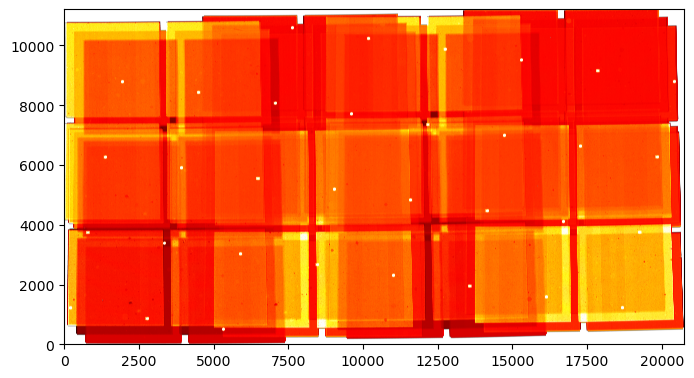

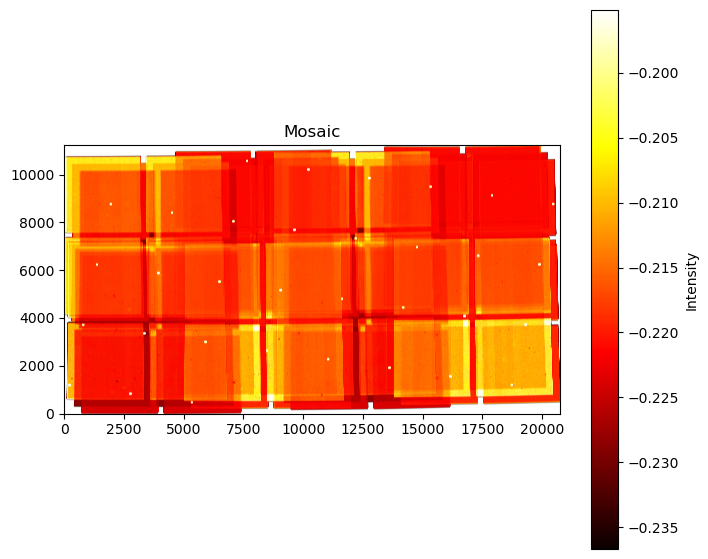

In [6]:
from astropy.visualization import ZScaleInterval
from astropy.visualization.mpl_normalize import ImageNormalize

%matplotlib inline
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

with fits.open(mosaic_file) as hdul:
    hdul.info()
    
    # ZScale is specifically designed for astronomical images
    norm = ImageNormalize(hdul['SCI'].data, interval=ZScaleInterval()) 
    im = ax.imshow(hdul['SCI'].data, cmap='hot', norm=norm, interpolation='gaussian', origin='lower')
    ax.set_title(f"Mosaic")
    plt.colorbar(im, ax=ax, label='Intensity')
plt.show()

In [7]:
from mopsf.inject import healpy_skycoords_in_footprint
mosaic_path = find_mosaic(MOSAIC_DIR, FILTER)
sci, wht, wcs, pixel_scale = load_mosaic(mosaic_path)
ny, nx = sci.shape
# ── known injection positions ────────────────────────────────────────────
edge_pad = 65 // 2 + 2
_, x_pos, y_pos = healpy_skycoords_in_footprint(
        wcs, nx, ny, nside=2**12, edge_pad=edge_pad
    )
print(x_pos,y_pos)
print(sci[np.round(y_pos).astype(int), np.round(x_pos).astype(int)])  # Print the pixel values at the injection positions

18:51:42  INFO  Using mosaic: /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic/nircam_F115W_mosaic_resample.fits
18:51:43  INFO  Loaded mosaic nircam_F115W_mosaic_resample.fits — shape (11217, 20750)


[  224.71666343   801.85226888  2781.36063443  1378.50882823
  3358.47123088  5337.91463328  1954.68662355  3935.10301305
  5915.00033606  7894.37898181  4511.2562629   6491.60745622
  8471.43990613  5086.93126215  7067.73627561  9048.02247933
 11027.79026278  7643.38707583  9624.12698315 11604.34840396
 13584.05172768 10199.75369907 12180.42870698 14160.58555166
 16140.22462251 12756.03145322 14736.64176854 16716.734244
 18696.30926892 15312.2206596  17292.76648928 19272.7948025
 17868.32163954 19848.80319062 20424.33471434] [ 1205.02373145  3721.15703685   847.83207569  6237.37709841
  3363.94800285   490.16195036  8753.68415309  5880.15072121
  3006.26070334   132.01353471  8396.44046766  5522.44628245
  2648.09531748 10912.81747913  8038.7189245   5164.26396121
  2289.45202422 10555.07886635  7680.51970262  4805.60393636
  1930.33100224 10196.8627785   7321.8429808   4446.4663865
  1570.73243003  9838.16939427  6962.68893759  4086.85149005
  1210.65648583  9478.99889214  6603.05775

In [28]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STEP 3 — measure the effective mosaic PSF (mPSF)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"\n{'='*60}")
print(f"  STEP 3 — ePSF measurement  [{FILTER}]")
print(f"{'='*60}\n")

mosaic_path = find_mosaic(MOSAIC_DIR, FILTER)

os.makedirs(OUTPUT_DIR, exist_ok=True)
epsf_path  = os.path.join(OUTPUT_DIR, f"{FILTER}_mpsf.fits")
stars_path = os.path.join(OUTPUT_DIR, f"{FILTER}_mpsf_stars.fits")

epsf, fitted_stars, stars_tbl = build_epsf(
    mosaic_path  = mosaic_path,
    filter_name  = FILTER,
    cutout_size  = 71,
    oversampling = 4,
    max_iters    = 20,
    min_flux_frac= 0.5,
    save_path    = epsf_path,
    save_stars   = stars_path,
)

print(f"\nmPSF shape : {epsf.data.shape}")
print(f"Stars used : {len(stars_tbl)}")
print(f"ePSF saved → {epsf_path}")
print(f"Stars saved→ {stars_path}")
print("\nDone.")

19:15:31  INFO  Using mosaic: /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic/nircam_F115W_mosaic_resample.fits



  STEP 3 — ePSF measurement  [F115W]



Set DATE-AVG to '2022-08-23T00:04:16.975' from MJD-AVG.
Set DATE-END to '2022-08-23T23:07:05.178' from MJD-END'. [astropy.wcs.wcs]
19:15:31  WARNING  FITSFixedWarning: 'datfix' made the change 'Set DATE-BEG to '2022-08-22T11:57:42.108' from MJD-BEG.
Set DATE-AVG to '2022-08-23T00:04:16.975' from MJD-AVG.
Set DATE-END to '2022-08-23T23:07:05.178' from MJD-END'.
Set OBSGEO-B to   -24.488168 from OBSGEO-[XYZ].
Set OBSGEO-H to 1574738043.483 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
19:15:31  WARNING  FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to   -55.652843 from OBSGEO-[XYZ].
Set OBSGEO-B to   -24.488168 from OBSGEO-[XYZ].
Set OBSGEO-H to 1574738043.483 from OBSGEO-[XYZ]'.
19:15:32  INFO  Loaded mosaic nircam_F115W_mosaic_resample.fits — shape (11217, 20750)
19:15:36  WARNING  Dropping 2/35 stars with peak < 50% of median
19:15:36  INFO  Building ePSF from 33 stars
19:15:36  INFO  Extracted 33 cutouts (cutout_size=71)


EPSFBuilder (20 maxiters):   0%|          | 0/20 [00:00<?, ?it/s]

19:15:55  INFO  ePSF built.  Shape: (71, 71)
19:15:55  INFO  ePSF written → /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_output/F115W_mpsf.fits
19:15:55  INFO  Star table → /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_output/F115W_mpsf_stars.fits



mPSF shape : (71, 71)
Stars used : 33
ePSF saved → /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_output/F115W_mpsf.fits
Stars saved→ /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_output/F115W_mpsf_stars.fits

Done.


In [29]:
print(epsf)

[[-2.95578604e-05 -2.10703790e-05 -2.02507127e-05 ... -2.17802152e-05
  -2.13803408e-05 -2.15368668e-05]
 [-3.29631602e-05 -2.18920164e-05 -2.09936987e-05 ... -2.17901966e-05
  -2.18169555e-05 -2.06125782e-05]
 [-3.18842788e-05 -2.14401194e-05 -2.14057006e-05 ... -2.14466382e-05
  -2.21334868e-05 -2.11068446e-05]
 ...
 [-3.32421160e-05 -2.21466481e-05 -2.21234465e-05 ... -2.18437571e-05
  -2.19648716e-05 -2.04756339e-05]
 [-3.29976069e-05 -2.23769793e-05 -2.23438977e-05 ... -2.10199802e-05
  -2.18793382e-05 -2.09709890e-05]
 [-3.16234346e-05 -2.20772390e-05 -2.23391984e-05 ... -2.04049812e-05
  -2.09078788e-05 -1.95791690e-05]]


In [30]:
with fits.open(epsf_path) as hdul:
    mpsf = hdul[0].data
    hdr = hdul[0].header
print(hdr)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -32 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                   71                                                  NAXIS2  =                   71                                                  FILTER  = 'F115W   '           / NIRCam filter                                  OVERSAMP=                    4 / ePSF oversampling factor                       CUTSIZE =                   71 / Cutout size (pixels)                           NSTARS  =                   33 / Number of stars used                           METHOD  = 'HEALPix injection + photutils EPSFBuilder'                           PIXELSC =                 0.02 / Pixel scale (arcsec/pixel)                     COMMENT mPSF following JADES DR5 (arXiv:2601.15954)                             END                                     

In [39]:
print(mpsf.shape)
print(np.sum(mpsf<0))

(71, 71)
3192


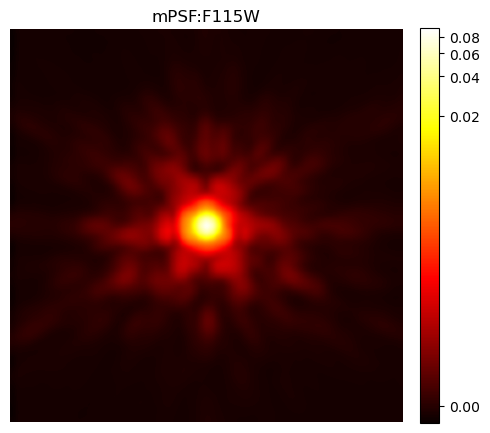

In [32]:
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
norm = simple_norm(mpsf, stretch='log')
im = ax.imshow(mpsf, cmap='hot', norm=norm, interpolation='gaussian', origin='lower')
ax.set_title("mPSF:"+FILTER)
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [33]:
pixel_scale = hdr['PIXELSC']
print(f"FWHM for mpsf")
print(f"pixel scale = {pixel_scale} arcsec/pixel")
fwhm_mpsf = fit_fwhm(mpsf)[0] * pixel_scale
print(f"PSF FWHM = {fwhm_mpsf} arcsec")

FWHM for mpsf
pixel scale = 0.02 arcsec/pixel
PSF FWHM = 0.053617362874786106 arcsec


In [34]:
from psfr.util import oversampled2regular
with fits.open("/RS2423/JWST/grism/data/direct_image/psfex/" + "psfex_"+FILTER+"_psf.fits") as hdul:
    hdul.info()
    psf_data = hdul[0].data
    hdr = hdul[0].header


Filename: /RS2423/JWST/grism/data/direct_image/psfex/psfex_F115W_psf.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (71, 71)   float64   


In [35]:
print(np.sum(psf_data),np.sum(mpsf))

1.0 1.0


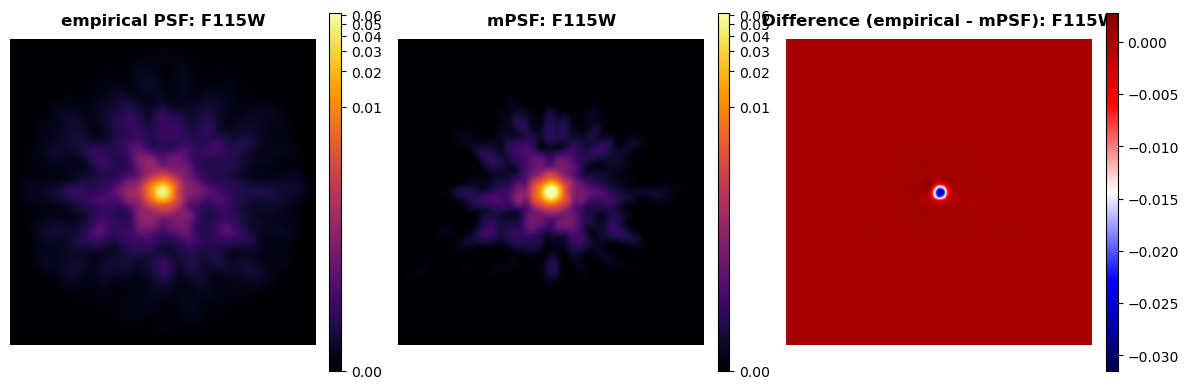

In [36]:
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from matplotlib.colors import TwoSlopeNorm,SymLogNorm
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
norm_psf = simple_norm(psf_data, stretch='log')
norm_diff = simple_norm(psf_data - mpsf, stretch='linear')  # Better for difference

# Subplot 1 - empirical PSF
im1 = axs[0].imshow(psf_data, cmap='inferno', norm=norm_psf, interpolation='gaussian', origin='lower')
axs[0].set_title(f"empirical PSF: {FILTER}", fontsize=12, fontweight='bold', pad=10)
axs[0].axis('off')
cbar1 = plt.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04, aspect=30)
cbar1.ax.tick_params(labelsize=10)

# Subplot 2 - mPSF
im2 = axs[1].imshow(mpsf, cmap='inferno', norm=norm_psf, interpolation='gaussian', origin='lower')
axs[1].set_title(f"mPSF: {FILTER}", fontsize=12, fontweight='bold', pad=10)
axs[1].axis('off')
cbar2 = plt.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04, aspect=30)
cbar2.ax.tick_params(labelsize=10)

# Subplot 2 - Difference (PSFEx - PSF)
#diff = psf_data - mpsf
#vmax = max(np.abs(diff).max(), 1e-10)
#linthresh = max(0.01 * vmax, 1e-8)
#im3 = axs[2].imshow(diff, cmap='RdBu_r',
#                    norm=SymLogNorm(linthresh=linthresh, linscale=0.5,
#                                    vmin=-vmax, vmax=vmax),
#                    interpolation='gaussian', origin='lower')
im3 = axs[2].imshow(psf_data-mpsf, cmap='seismic', norm=norm_diff, interpolation='gaussian', origin='lower')
axs[2].set_title(f"Difference (empirical - mPSF): {FILTER}", fontsize=12, fontweight='bold', pad=10)
axs[2].axis('off')
cbar3 = plt.colorbar(im3, ax=axs[2], fraction=0.046, pad=0.04, aspect=30)
cbar3.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

In [37]:
hdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   71                                                  
NAXIS2  =                   71                                                  
EXTEND  =                    T                                                  

In [38]:
print(f"FWHM for empirical PSF")
print(f"pixel scale = {pixel_scale} arcsec/pixel")
fwhm_stacked_psfex = fit_fwhm(psf_data)[0] * pixel_scale
print(f"PSF FWHM = {fwhm_stacked_psfex} arcsec")

FWHM for empirical PSF
pixel scale = 0.02 arcsec/pixel
PSF FWHM = 0.06066407267414343 arcsec
